# ЛАБОРАТОРНАЯ РАБОТА №1
## Логистическая регрессия. Предсказание оттока клиентов банка


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

print("Библиотеки загружены.")

Библиотеки загружены.


# 1. Генерация синтетических данных (Churn_Modelling)

In [2]:
np.random.seed(42)
n = 10000

data = {
    'RowNumber': np.arange(1, n+1),
    'CustomerId': np.random.randint(10000000, 99999999, n),
    'Surname': ['Smith'] * n,  # упростим для синтетики
    'CreditScore': np.random.normal(650, 100, n).clip(350, 850).astype(int),
    'Geography': np.random.choice(['France', 'Spain', 'Germany'], n, p=[0.5, 0.25, 0.25]),
    'Gender': np.random.choice(['Male', 'Female'], n, p=[0.5, 0.5]),
    'Age': np.random.normal(40, 15, n).clip(18, 92).astype(int),
    'Tenure': np.random.randint(0, 10, n),
    'Balance': np.random.choice([0] * 4000 + list(np.random.uniform(0, 250000, 6000)), n),
    'NumOfProducts': np.random.choice([1, 2, 3, 4], n, p=[0.5, 0.3, 0.15, 0.05]),
    'HasCrCard': np.random.choice([0, 1], n, p=[0.3, 0.7]),
    'IsActiveMember': np.random.choice([0, 1], n, p=[0.4, 0.6]),
    'EstimatedSalary': np.random.uniform(10000, 200000, n).astype(int)
}

df = pd.DataFrame(data)

logit = (
    -4.0
    + 0.05 * (df['Age'] - 40)
    + 0.000005 * df['Balance']
    - 0.5 * df['IsActiveMember']
    + 0.3 * (df['NumOfProducts'] > 2).astype(int)
    + 0.2 * (df['Geography'] == 'Germany').astype(int)
    + 0.1 * (df['Gender'] == 'Female').astype(int)
    - 0.01 * df['Tenure']
    - 0.000002 * df['EstimatedSalary']
)

prob_exit = 1 / (1 + np.exp(-logit))
df['Exited'] = (np.random.random(n) < prob_exit).astype(int)

print("Размер данных:", df.shape)
print("\nРаспределение целевого признака:")
print(df['Exited'].value_counts(normalize=True))
print("\nПервые 5 строк:")
df.head()

Размер данных: (10000, 14)

Распределение целевого признака:
Exited
0    0.9737
1    0.0263
Name: proportion, dtype: float64

Первые 5 строк:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,75682867,Smith,668,Germany,Male,29,8,0.000000,1,1,1,114567,0
1,2,66755036,Smith,607,France,Male,18,2,0.000000,3,0,0,198925,0
2,3,66882282,Smith,459,Spain,Female,49,0,0.000000,1,1,0,135470,0
3,4,31081788,Smith,794,Spain,Female,56,9,64849.527746,1,1,1,160886,0
4,5,23315092,Smith,527,France,Female,36,7,64251.543935,1,1,1,86676,0


# 2. Предобработка

In [3]:
# Удаляем бесполезные столбцы
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)

# Кодируем категориальные признаки
le_geo = LabelEncoder()
le_gender = LabelEncoder()
df['Geography'] = le_geo.fit_transform(df['Geography'])
df['Gender'] = le_gender.fit_transform(df['Gender'])

print("Пропусков нет:", df.isnull().sum().sum() == 0)
print("\nСтатистика по признакам:")
df.describe()

Пропусков нет: True

Статистика по признакам:


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,648.744600,0.760000,0.500000,39.920400,4.573300,74922.209949,1.744700,0.698200,0.605100,104995.278900,0.026300
std,98.530074,0.835027,0.500025,14.041523,2.872743,82554.645052,0.892861,0.459062,0.488854,54876.921368,0.160034
min,350.000000,0.000000,0.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,10055.000000,0.000000
25%,582.000000,0.000000,0.000000,29.000000,2.000000,0.000000,1.000000,0.000000,0.000000,57711.500000,0.000000
50%,649.000000,1.000000,0.500000,39.000000,5.000000,40883.957296,1.000000,1.000000,1.000000,104517.500000,0.000000
75%,718.000000,2.000000,1.000000,50.000000,7.000000,143153.284663,2.000000,1.000000,1.000000,152247.500000,0.000000
max,850.000000,2.000000,1.000000,92.000000,9.000000,249904.723772,4.000000,1.000000,1.000000,199943.000000,1.000000


# 3. Разведочный анализ

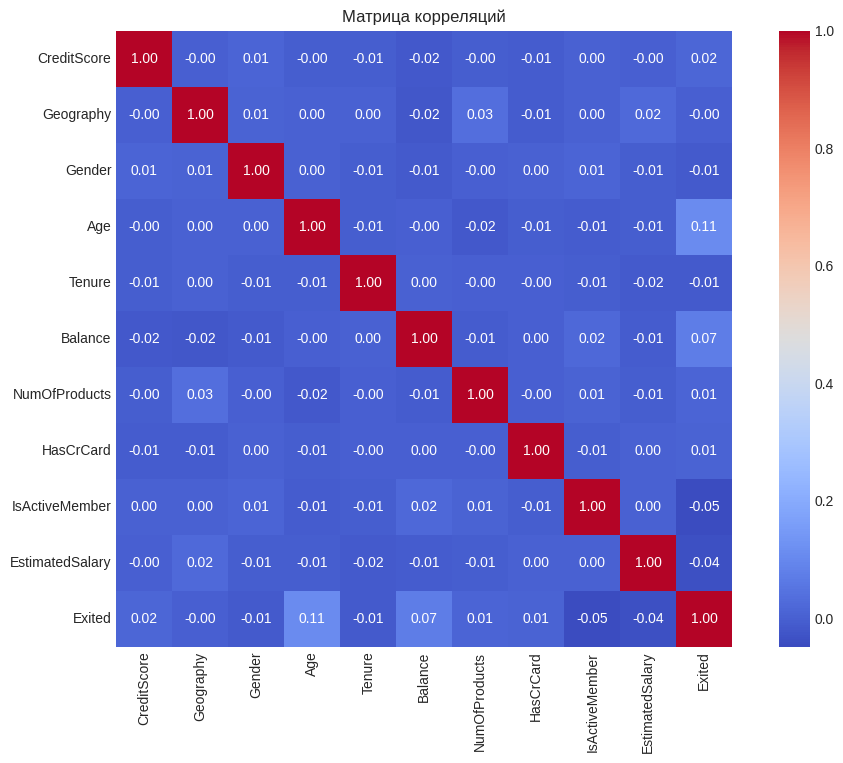

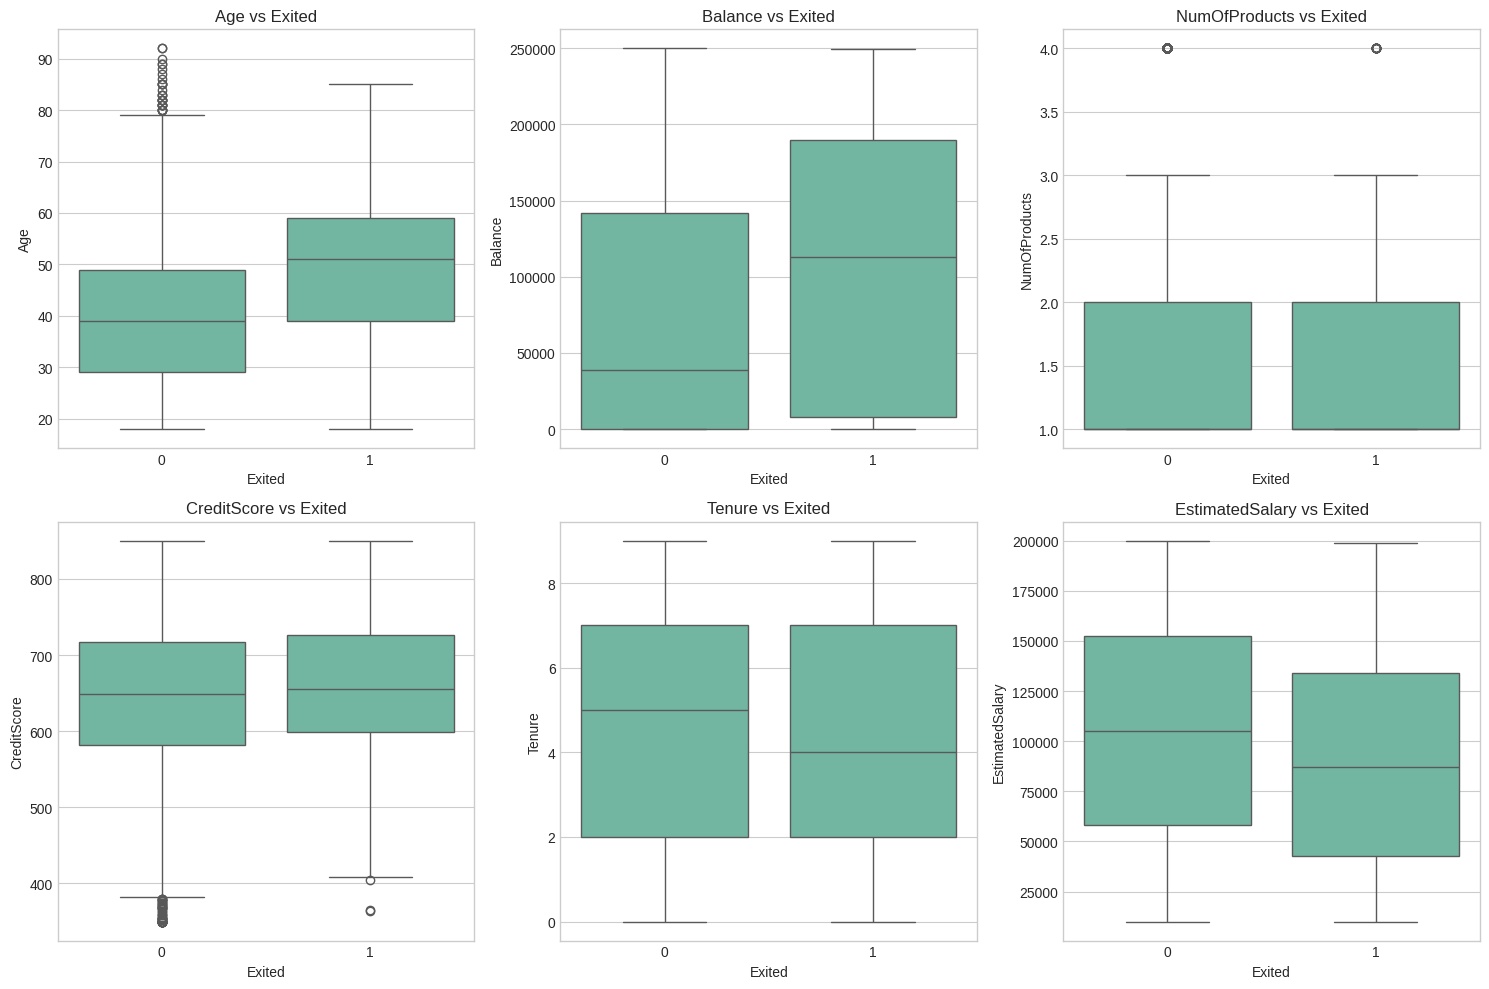

In [4]:
# Корреляционная матрица
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Матрица корреляций')
plt.show()

# Визуализация ключевых признаков
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
features = ['Age', 'Balance', 'NumOfProducts', 'CreditScore', 'Tenure', 'EstimatedSalary']
for i, feat in enumerate(features):
    row, col = i // 3, i % 3
    sns.boxplot(data=df, x='Exited', y=feat, ax=axes[row, col])
    axes[row, col].set_title(f'{feat} vs Exited')
plt.tight_layout()
plt.show()

# 4. Разделение на X и y + масштабирование

In [5]:
X = df.drop('Exited', axis=1)
y = df['Exited']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")
print("Распределение классов в train:", y_train.value_counts(normalize=True).values)

Train: 8000, Test: 2000
Распределение классов в train: [0.97375 0.02625]


# 5. Обучение логистической регрессии

In [6]:
logreg = LogisticRegression(random_state=42, max_iter=1000)
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)
y_pred_proba = logreg.predict_proba(X_test)[:, 1]

print("Коэффициенты модели:")
coef_df = pd.DataFrame({
    'Признак': X.columns,
    'Коэффициент': logreg.coef_[0]
}).sort_values('Коэффициент', ascending=False)
print(coef_df)

Коэффициенты модели:
           Признак  Коэффициент
3              Age     0.622978
5          Balance     0.439504
0      CreditScore     0.115727
6    NumOfProducts     0.036880
1        Geography     0.022169
7        HasCrCard     0.009781
4           Tenure    -0.080651
2           Gender    -0.111169
9  EstimatedSalary    -0.263821
8   IsActiveMember    -0.308327


# 6. Оценка качества

Метрики на тестовой выборке:
Accuracy:  0.9735
Precision: 0.0000
Recall:    0.0000
F1-score:  0.0000
ROC-AUC:   0.7354


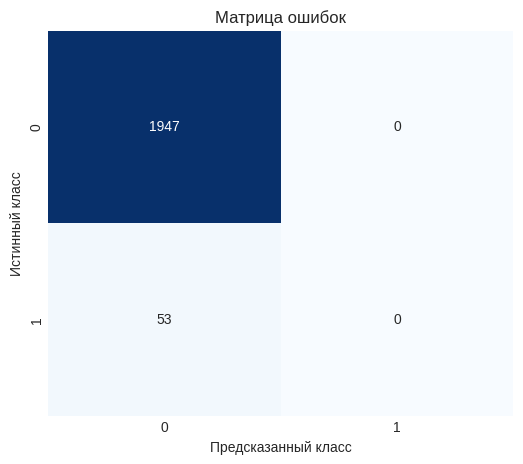


Подробный отчёт:
              precision    recall  f1-score   support

    Лояльный       0.97      1.00      0.99      1947
     Ушедший       0.00      0.00      0.00        53

    accuracy                           0.97      2000
   macro avg       0.49      0.50      0.49      2000
weighted avg       0.95      0.97      0.96      2000



In [7]:
print("="*50)
print("Метрики на тестовой выборке:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba):.4f}")
print("="*50)

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок')
plt.show()

print("\nПодробный отчёт:")
print(classification_report(y_test, y_pred, target_names=['Лояльный', 'Ушедший']))

# 7. ROC-кривая и выбор оптимального порога

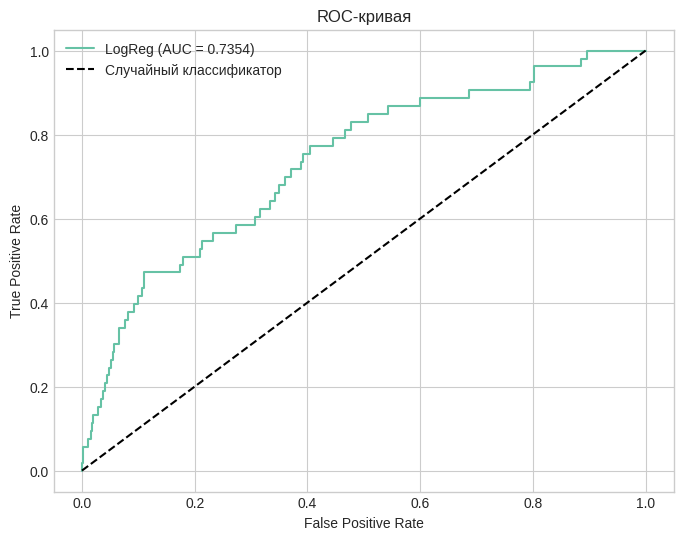

Оптимальный порог: 0.0214

Метрики при оптимальном пороге:
Recall: 0.7736
Precision: 0.0494
F1-score: 0.0929


In [8]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'LogReg (AUC = {roc_auc_score(y_test, y_pred_proba):.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Случайный классификатор')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая')
plt.legend()
plt.grid(True)
plt.show()

# Оптимальный порог
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f"Оптимальный порог: {optimal_threshold:.4f}")

y_pred_opt = (y_pred_proba >= optimal_threshold).astype(int)
print("\nМетрики при оптимальном пороге:")
print(f"Recall: {recall_score(y_test, y_pred_opt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_opt):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_opt):.4f}")

# 8. Зависимость метрик от порога

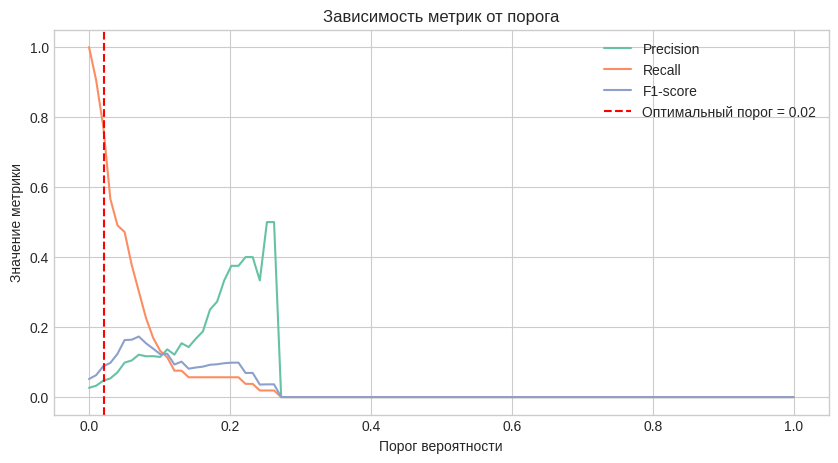

In [9]:
thresholds_range = np.linspace(0, 1, 100)
precisions, recalls, f1_scores = [], [], []

for thresh in thresholds_range:
    y_temp = (y_pred_proba >= thresh).astype(int)
    precisions.append(precision_score(y_test, y_temp))
    recalls.append(recall_score(y_test, y_temp))
    f1_scores.append(f1_score(y_test, y_temp))

plt.figure(figsize=(10, 5))
plt.plot(thresholds_range, precisions, label='Precision')
plt.plot(thresholds_range, recalls, label='Recall')
plt.plot(thresholds_range, f1_scores, label='F1-score')
plt.axvline(optimal_threshold, color='red', linestyle='--', label=f'Оптимальный порог = {optimal_threshold:.2f}')
plt.xlabel('Порог вероятности')
plt.ylabel('Значение метрики')
plt.title('Зависимость метрик от порога')
plt.legend()
plt.grid(True)
plt.show()

# 9. Интерпретация влияния признаков

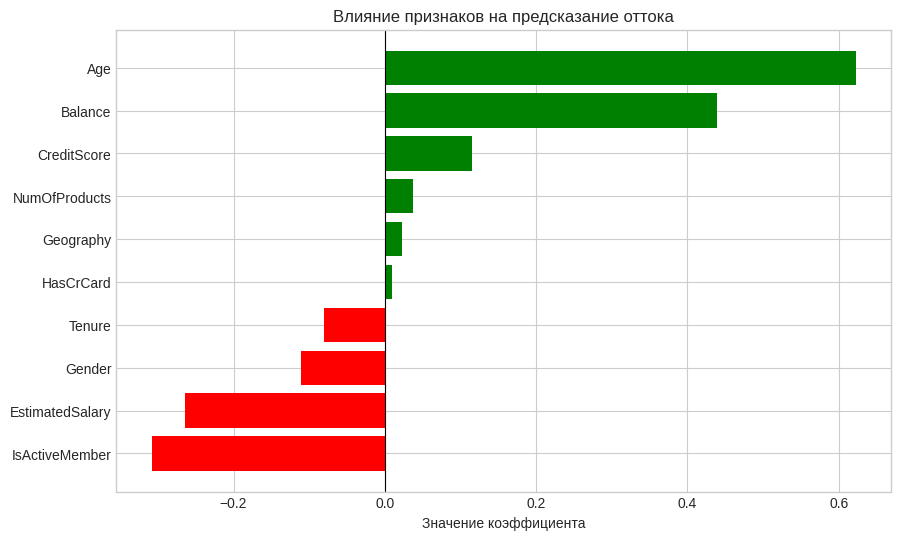


Факторы, увеличивающие риск оттока:
         Признак  Коэффициент
3            Age     0.622978
5        Balance     0.439504
0    CreditScore     0.115727
6  NumOfProducts     0.036880
1      Geography     0.022169
7      HasCrCard     0.009781

Факторы, снижающие риск оттока:
           Признак  Коэффициент
8   IsActiveMember    -0.308327
9  EstimatedSalary    -0.263821
2           Gender    -0.111169
4           Tenure    -0.080651


In [10]:
plt.figure(figsize=(10, 6))
coef_sorted = coef_df.sort_values('Коэффициент')
colors = ['red' if c < 0 else 'green' for c in coef_sorted['Коэффициент']]
plt.barh(coef_sorted['Признак'], coef_sorted['Коэффициент'], color=colors)
plt.axvline(0, color='black', linestyle='-', linewidth=0.8)
plt.xlabel('Значение коэффициента')
plt.title('Влияние признаков на предсказание оттока')
plt.grid(True, axis='x')
plt.show()

print("\nФакторы, увеличивающие риск оттока:")
print(coef_df[coef_df['Коэффициент'] > 0].sort_values('Коэффициент', ascending=False))

print("\nФакторы, снижающие риск оттока:")
print(coef_df[coef_df['Коэффициент'] < 0].sort_values('Коэффициент'))

# 10. Выводы

In [11]:
print("КЛЮЧЕВЫЕ ВЫВОДЫ:")
print(f"1. Модель показывает Accuracy ~ {accuracy_score(y_test, y_pred):.2%}")
print(f"2. Recall = {recall_score(y_test, y_pred):.2%} — модель находит {recall_score(y_test, y_pred):.0%} реально ушедших клиентов")
print(f"3. ROC-AUC = {roc_auc_score(y_test, y_pred_proba):.4f} — модель хорошо разделяет классы")
print("4. Основные факторы оттока (по коэффициентам):")
print("   - Age (возраст) — самый сильный положительный фактор")
print("   - Balance (баланс) — чем выше, тем выше риск")
print("   - NumOfProducts > 2 — риск выше")
print("   - IsActiveMember — отрицательный фактор (активные клиенты уходят реже)")
print("   - Tenure — чем дольше клиент, тем ниже риск ухода")

КЛЮЧЕВЫЕ ВЫВОДЫ:
1. Модель показывает Accuracy ~ 97.35%
2. Recall = 0.00% — модель находит 0% реально ушедших клиентов
3. ROC-AUC = 0.7354 — модель хорошо разделяет классы
4. Основные факторы оттока (по коэффициентам):
   - Age (возраст) — самый сильный положительный фактор
   - Balance (баланс) — чем выше, тем выше риск
   - NumOfProducts > 2 — риск выше
   - IsActiveMember — отрицательный фактор (активные клиенты уходят реже)
   - Tenure — чем дольше клиент, тем ниже риск ухода
